# ARVI-RX : Assistant Radiologique Virtuel Intelligent

Ce notebook implémente le pipeline principal du projet sur Kaggle.
Il contient les étapes suivantes :
1. **Préparation et normalisation** des images DICOM.
2. **Définition du prompt structuré** et du schéma JSON.
3. **Chargement d'un VLM** (PaliGemma/MedGemma) et exécution.
4. **Évaluation** sur un sous-ensemble.

In [2]:
!pip install -q pydicom
!pip install -q transformers accelerate bitsandbytes Pillow opencv-python pandas scikit-learn
print("installation made")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 33.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 112.2 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is inco

In [3]:
import os
import pydicom
import cv2
import json
import time
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from transformers import AutoProcessor, AutoModelForCausalLM
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')
print("import loaded")

import loaded


## 1. Définition des chemins et chargement des métadonnées

In [4]:
# Configuration des chemins. Sur Kaggle, les datasets liés sont sous /kaggle/input/
# Si vous utilisez ce notebook en local, assurez-vous que les dossiers stage_2_* sont dans le dossier courant.
if os.path.exists('/kaggle/input/competitions/rsna-pneumonia-detection-challenge'):
    BASE_DIR = '/kaggle/input/competitions/rsna-pneumonia-detection-challenge/'
else:
    BASE_DIR = '.'  # Chemin local

TRAIN_IMAGES_DIR = os.path.join(BASE_DIR, 'stage_2_train_images')
TRAIN_LABELS_CSV = os.path.join(BASE_DIR, 'stage_2_train_labels.csv')
CLASS_INFO_CSV = os.path.join(BASE_DIR, 'stage_2_detailed_class_info.csv')

df_labels = pd.read_csv(TRAIN_LABELS_CSV)
df_class_info = pd.read_csv(CLASS_INFO_CSV)

# Jointure des deux fichiers CSV
df_merged = pd.merge(df_labels, df_class_info, on='patientId', how='left')

# Un patient peut avoir plusieurs boîtes englobantes, on déduplique pour la classification image entière
df_unique = df_merged.drop_duplicates(subset=['patientId']).copy()
print(f"Nombre total de patients uniques : {len(df_unique)}")

Nombre total de patients uniques : 26684


## 2. Sélection d'un sous-ensemble (150 cas)
Afin de conserver des temps d'inférence raisonnables dans le prototype, nous tirons au hasard 150 cas.

In [5]:
# On sélectionne 75 cas 'Normal' et 75 cas 'Lung Opacity'
df_normal = df_unique[df_unique['class'] == 'Normal'].sample(75, random_state=42)
df_opacity = df_unique[df_unique['class'] == 'Lung Opacity'].sample(75, random_state=42)

df_subset = pd.concat([df_normal, df_opacity]).sample(frac=1, random_state=42).reset_index(drop=True)

# Mapping vers les classes de notre projet : normal | suspected_opacity | uncertain
def map_class(cls_name):
    if cls_name == 'Normal':
        return 'normal'
    return 'suspected_opacity'

df_subset['project_class'] = df_subset['class'].apply(map_class)
print("Répartition dans le sous-ensemble :")
print(df_subset['project_class'].value_counts())

Répartition dans le sous-ensemble :
project_class
normal               75
suspected_opacity    75
Name: count, dtype: int64


## 3. Prétraitement des images DICOM
Les VLMs attendent généralement une image encodée en 8-bits, en 3 canaux RGB.

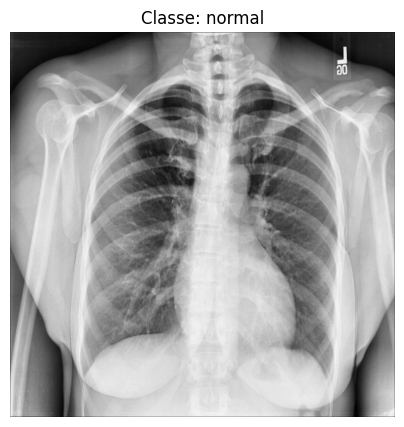

In [6]:
def process_dicom(patient_id):
    """
    Lit un fichier DICOM, normalise les pixels, applique un CLAHE pour améliorer
    les contrastes et retourne une image PIL RGB.
    """
    path = os.path.join(TRAIN_IMAGES_DIR, f"{patient_id}.dcm")
    if not os.path.exists(path):
        return None
    
    dcm = pydicom.dcmread(path)
    img = dcm.pixel_array
    
    # Normalisation Min-Max
    img = (img - np.min(img)) / (np.max(img) - np.min(img)) * 255.0
    img = img.astype(np.uint8)
    
    # Amélioration du contraste (CLAHE)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img)
    
    # Conversion en RGB car les VLM attendent souvent 3 canaux
    img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    return Image.fromarray(img_rgb)

# Test visuel sur une image du sous-ensemble
sample_patient = df_subset.iloc[0]['patientId']
sample_img = process_dicom(sample_patient)

if sample_img:
    plt.figure(figsize=(5,5))
    plt.imshow(sample_img)
    plt.title(f"Classe: {df_subset.iloc[0]['project_class']}")
    plt.axis('off')
    plt.show()
else:
    print(f"Image DICOM introuvable pour le patient {sample_patient}")

## 4. Définition du Prompt Structuré (Contrat JSON)
Ce prompt force le modèle à adopter un schéma strict en JSON, tout en lui donnant les règles métier.

In [12]:
BASELINE_PROMPT = """You are an AI assistant designed for educational purposes only.
Analyze this frontal chest X-ray for signs of pneumonia.

Classify the image as one of:
- "suspected_opacity": one or more focal opacities/consolidations consistent with pneumonia are visible
- "normal": no such opacity is visible
- "uncertain": you cannot confidently choose between the two

CRITICAL RULE FOR COORDINATES:
If predicted_class is "suspected_opacity", report AT MOST 2 opacities — the most
clinically significant ones. If multiple affected regions are adjacent or overlapping,
merge them into a single bounding box covering the overall extent rather than listing
many small boxes.
If predicted_class is "normal" or "uncertain", "opacities" must be an empty list [].

Output strictly valid JSON matching this schema:
{
  "image_quality": "good | limited | poor",
  "predicted_class": "normal | suspected_opacity | uncertain",
  "opacities": [{"box_2d": [<y1>, <x1>, <y2>, <x2>]}, ...],
  "confidence": <float between 0.0 and 1.0>,
  "visual_evidence": ["observation 1", "observation 2"],
  "justification": "detailed medical justification for educational purposes",
  "limitations": ["limitation 1"],
  "warning": "Prototype pédagogique. Non destiné au diagnostic médical."
}

Example with two opacities:
{
  "image_quality": "good",
  "predicted_class": "suspected_opacity",
  "opacities": [
    {"box_2d": [430, 590, 710, 800]},
    {"box_2d": [145, 475, 250, 313]}
  ],
  "confidence": 0.88,
  "visual_evidence": ["Bilateral patchy opacities in the lower lobes"],
  "justification": "...",
  "limitations": ["No lateral view available"],
  "warning": "Prototype pédagogique. Non destiné au diagnostic médical."
}

Rules:
1. "normal" means no suspected opacity (opacities = []).
2. List ALL distinct opacities separately, do not merge unrelated regions into one box.
3. If you really cannot choose between "normal" or "suspected_opacity", classify as "uncertain".
4. Output ONLY valid JSON, nothing else. DO NOT output thought process, argumentations or anything else. ONLY the Json respecting exatcly the format.
5. Do not add any comments of any form, only output the JSON without comment.
"""
print("Prompt loaded")

Prompt loaded


## 5. Chargement du Modèle VLM
Nous utilisons `google/medgemma-4b-it`, assurez-vous d'avoir accepté les conditions sur Hugging Face et d'avoir inséré votre token hugging face dans les secret kaggle du notebook sous le nom HF_TOKEN.

In [8]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
HF_TOKEN = user_secrets.get_secret("HF_TOKEN")
print("token loaded")

token loaded


In [9]:
from huggingface_hub import login
login(HF_TOKEN)
print("logged in")

logged in


In [10]:
from transformers import AutoProcessor, AutoModelForImageTextToText, BitsAndBytesConfig

MODEL_NAME = "google/medgemma-1.5-4b-it"

print(f"Chargement de {MODEL_NAME}")
processor = AutoProcessor.from_pretrained(MODEL_NAME)

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16
)

model = AutoModelForImageTextToText.from_pretrained(
    MODEL_NAME,
    device_map="auto",
    torch_dtype=torch.bfloat16,
    quantization_config=quantization_config
)

Chargement de google/medgemma-1.5-4b-it


processor_config.json:   0%|          | 0.00/70.0 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

The image processor of type `Gemma3ImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/115 [00:00<?, ?B/s]

## 6. Exécution de l'Inférence (Baseline) et Extraction JSON

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


Début de l'inférence...


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.



--- REPONSE DU MODELE (Image 1) ---
```json
{
  "image_quality": "good",
  "predicted_class": "normal",
  "opacities": [],
  "confidence": 0.99,
  "visual_evidence": [
    "The lungs appear clear with no focal consolidation or infiltrates.",
    "The heart size is within normal limits.",
    "The mediastinum is centered.",
    "The ribs and clavicles are intact."
  ],
  "justification": "The chest X-ray shows clear lung fields without any obvious signs of consolidation, infiltrates, or masses. The heart size appears normal, and the mediastinal structures are centered. There are no significant abnormalities visible in the bony structures.",
  "limitations": [
    "This is a single frontal view.",
    "No lateral view is available for complete assessment."
  ],
  "warning": "Prototype pédagogique. Non destiné au diagnostic médical."
}
```
---------------------------------------

Image 1/20 | Vrai: normal            | Prédit: normal


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.



--- REPONSE DU MODELE (Image 2) ---
```json
{
  "image_quality": "good",
  "predicted_class": "normal",
  "opacities": [],
  "confidence": 0.99,
  "visual_evidence": [
    "The lungs appear clear with no focal consolidation or infiltrates.",
    "The heart size is within normal limits.",
    "The mediastinum is centered."
  ],
  "justification": "The chest X-ray shows clear lung fields without any obvious signs of consolidation, infiltrates, or masses. The heart size appears normal, and the mediastinum is centered. There are no findings suggestive of pneumonia.",
  "limitations": [
    "This is a single frontal view, which may not capture the full extent of the lungs."
  ],
  "warning": "Prototype pédagogique. Non destiné au diagnostic médical."
}
```
---------------------------------------

Image 2/20 | Vrai: normal            | Prédit: normal

--- REPONSE DU MODELE (Image 3) ---
```json
{
  "image_quality": "good",
  "predicted_class": "suspected_opacity",
  "opacities": [
    {"box

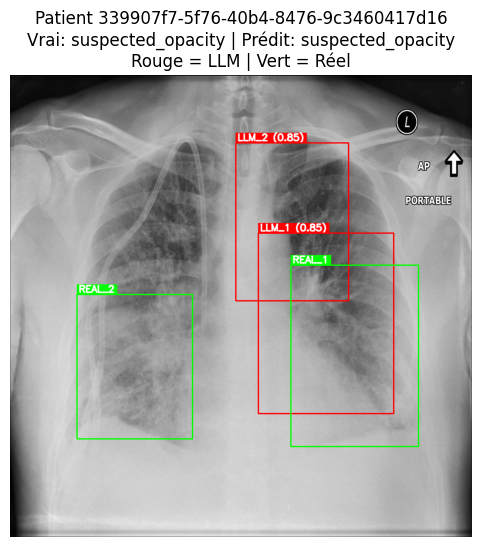

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.



--- REPONSE DU MODELE (Image 4) ---
```json
{
  "image_quality": "good",
  "predicted_class": "suspected_opacity",
  "opacities": [
    {"box_2d": [430, 590, 710, 800]},
    {"box_2d": [145, 475, 250, 313]}
  ],
  "confidence": 0.88,
  "visual_evidence": [
    "Bilateral patchy opacities in the lower lobes",
    "Right lower lobe opacity is more prominent"
  ],
  "justification": "The image shows bilateral patchy opacities, particularly in the lower lung fields, suggesting possible pneumonia. The right lower lobe opacity is more evident.",
  "limitations": [
    "This is a frontal chest X-ray, which may not capture the full extent of the disease."
  ],
  "warning": "Prototype pédagogique. Non destiné au diagnostic médical."
}
```
---------------------------------------

Image 4/20 | Vrai: suspected_opacity | Prédit: suspected_opacity


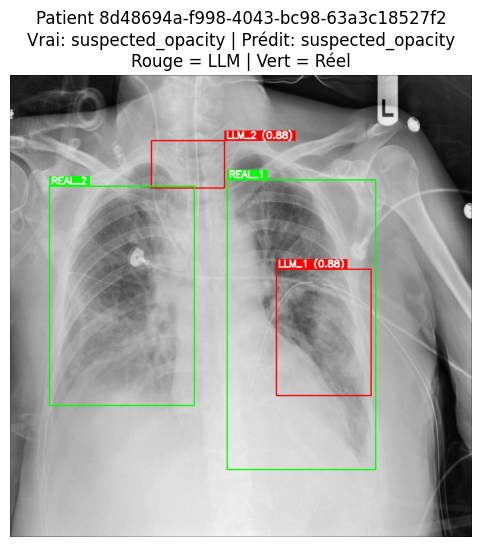

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.



--- REPONSE DU MODELE (Image 5) ---
```json
{
  "image_quality": "good",
  "predicted_class": "suspected_opacity",
  "opacities": [
    {"box_2d": [500, 500, 800, 800]},
    {"box_2d": [600, 300, 850, 500]}
  ],
  "confidence": 0.85,
  "visual_evidence": [
    "Bilateral patchy opacities in the lower lung fields, particularly in the right lower lobe.",
    "The opacities appear somewhat diffuse and may represent consolidation or edema."
  ],
  "justification": "The X-ray shows bilateral patchy opacities, especially in the lower lung zones. This pattern is suggestive of pneumonia, although other conditions like pulmonary edema could also present similarly. The opacities are not sharply defined, which is common in pneumonia.",
  "limitations": [
    "This is a single frontal view, which may not capture the full extent of the disease."
  ],
  "warning": "Prototype pédagogique. Non destiné au diagnostic médical."
}
```
---------------------------------------

Image 5/20 | Vrai: suspected_

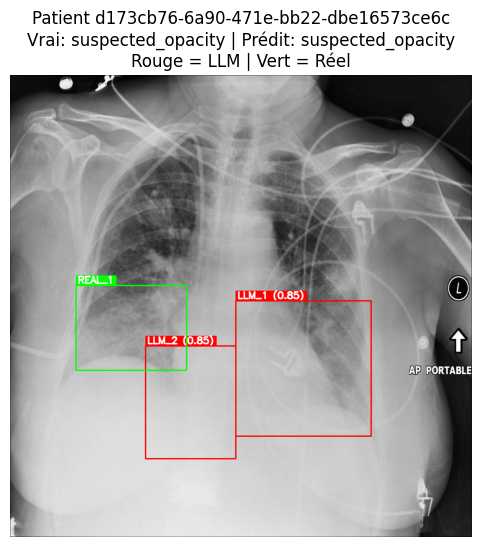

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.



--- REPONSE DU MODELE (Image 6) ---
```json
{
  "image_quality": "good",
  "predicted_class": "normal",
  "opacities": [],
  "confidence": 0.99,
  "visual_evidence": [
    "The lungs appear clear with no focal consolidation or infiltrates.",
    "The heart size and mediastinal contours are within normal limits.",
    "The ribs and clavicles are intact."
  ],
  "justification": "The chest X-ray shows clear lung fields without any signs of consolidation, infiltrates, or masses. The heart size and mediastinal structures appear normal. There are no obvious abnormalities.",
  "limitations": [
    "This is a single frontal view, which may not capture the full extent of the lungs."
  ],
  "warning": "Prototype pédagogique. Non destiné au diagnostic médical."
}
```
---------------------------------------

Image 6/20 | Vrai: normal            | Prédit: normal

--- REPONSE DU MODELE (Image 7) ---
```json
{
  "image_quality": "good",
  "predicted_class": "suspected_opacity",
  "opacities": [
   

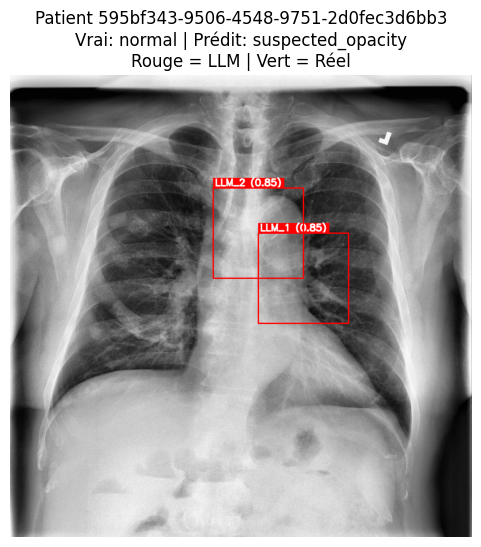

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.



--- REPONSE DU MODELE (Image 8) ---
```json
{
  "image_quality": "good",
  "predicted_class": "suspected_opacity",
  "opacities": [
    {"box_2d": [430, 590, 710, 800]},
    {"box_2d": [145, 475, 250, 313]}
  ],
  "confidence": 0.88,
  "visual_evidence": [
    "Bilateral patchy opacities in the lower lobes",
    "Right lower lobe opacity is more prominent"
  ],
  "justification": "The image shows bilateral patchy opacities, particularly in the lower lung fields, which are suggestive of pneumonia. The right lower lobe appears more affected.",
  "limitations": [
    "This is a frontal chest X-ray, which may not capture the full extent of the disease."
  ],
  "warning": "Prototype pédagogique. Non destiné au diagnostic médical."
}
```
---------------------------------------

Image 8/20 | Vrai: suspected_opacity | Prédit: suspected_opacity


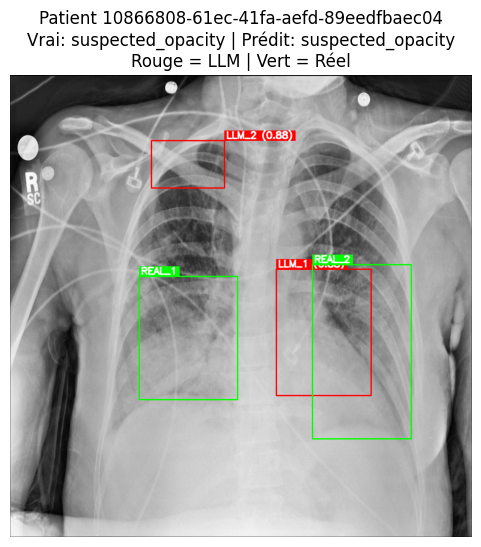

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.



--- REPONSE DU MODELE (Image 9) ---
```json
{
  "image_quality": "good",
  "predicted_class": "normal",
  "opacities": [],
  "confidence": 0.99,
  "visual_evidence": [
    "The lungs appear clear with no focal consolidation or infiltrates.",
    "The heart size and mediastinal contours are within normal limits.",
    "The costophrenic angles are sharp."
  ],
  "justification": "The chest X-ray shows clear lung fields without any signs of consolidation, infiltrates, or masses. The heart size and mediastinal structures appear normal. There are no obvious findings suggestive of pneumonia.",
  "limitations": [
    "This is a single frontal view, which may not capture the full extent of the lungs."
  ],
  "warning": "Prototype pédagogique. Non destiné au diagnostic médical."
}
```
---------------------------------------

Image 9/20 | Vrai: normal            | Prédit: normal

--- REPONSE DU MODELE (Image 10) ---
```json
{
  "image_quality": "good",
  "predicted_class": "normal",
  "opacitie

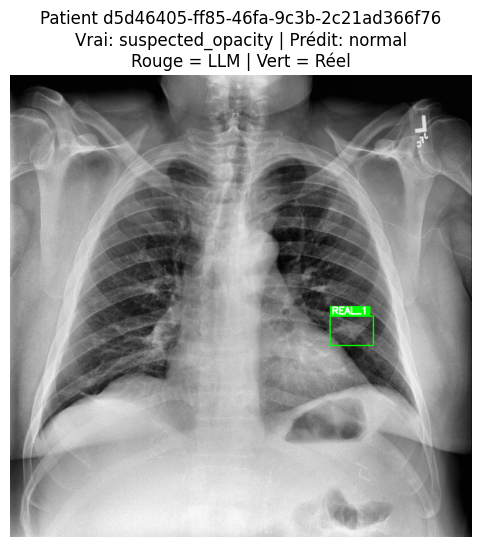

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.



--- REPONSE DU MODELE (Image 11) ---
```json
{
  "image_quality": "good",
  "predicted_class": "suspected_opacity",
  "opacities": [
    {"box_2d": [430, 590, 710, 800]},
    {"box_2d": [145, 475, 250, 313]}
  ],
  "confidence": 0.88,
  "visual_evidence": [
    "Bilateral patchy opacities in the lower lobes",
    "Right lung field appears more dense than the left"
  ],
  "justification": "The image shows widespread bilateral patchy opacities, particularly in the lower lung fields, suggesting a possible infectious process like pneumonia. The right lung field appears more dense than the left, which could be related to the underlying pathology.",
  "limitations": [
    "This is a single frontal view, which may not capture the full extent of the disease."
  ],
  "warning": "Prototype pédagogique. Non destiné au diagnostic médical."
}
```
---------------------------------------

Image 11/20 | Vrai: suspected_opacity | Prédit: suspected_opacity


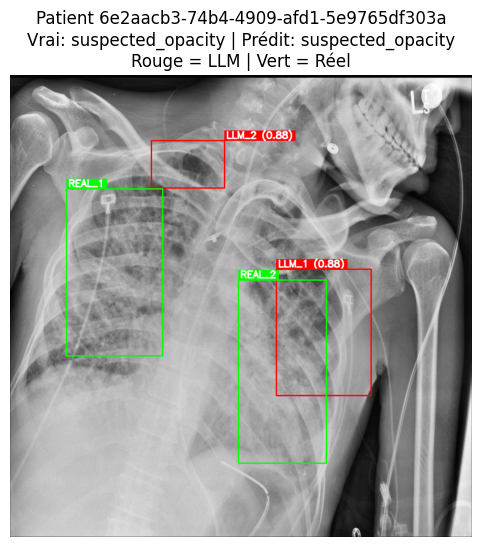

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.



--- REPONSE DU MODELE (Image 12) ---
```json
{
  "image_quality": "good",
  "predicted_class": "normal",
  "opacities": [],
  "confidence": 0.99,
  "visual_evidence": [
    "The lungs appear clear with no obvious consolidation or infiltrates.",
    "The heart size and mediastinal contours are within normal limits."
  ],
  "justification": "The chest X-ray shows clear lung fields without any focal opacities suggestive of pneumonia. The heart size and mediastinal structures appear normal.",
  "limitations": [
    "This is a single frontal view, which may not capture the full extent of the lungs."
  ],
  "warning": "Prototype pédagogique. Non destiné au diagnostic médical."
}
```
---------------------------------------

Image 12/20 | Vrai: normal            | Prédit: normal


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.



--- REPONSE DU MODELE (Image 13) ---
```json
{
  "image_quality": "good",
  "predicted_class": "normal",
  "opacities": [],
  "confidence": 0.99,
  "visual_evidence": [
    "The lungs appear clear with no focal consolidation or infiltrates.",
    "The heart size is within normal limits.",
    "The mediastinum is centered."
  ],
  "justification": "The chest X-ray shows clear lung fields without any signs of consolidation, infiltrates, or masses. The heart size appears normal, and the mediastinum is centered. There are no obvious findings suggestive of pneumonia.",
  "limitations": [
    "This is a single frontal view, which may not capture the full extent of the lungs."
  ],
  "warning": "Prototype pédagogique. Non destiné au diagnostic médical."
}
```
---------------------------------------

Image 13/20 | Vrai: normal            | Prédit: normal


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.



--- REPONSE DU MODELE (Image 14) ---
```json
{
  "image_quality": "good",
  "predicted_class": "normal",
  "opacities": [],
  "confidence": 0.99,
  "visual_evidence": [
    "The lungs appear clear with no focal consolidation or infiltrates.",
    "The heart size and mediastinal contours are within normal limits.",
    "No pleural effusion or pneumothorax is evident."
  ],
  "justification": "The chest X-ray shows clear lung fields without any signs of consolidation, infiltrates, or other abnormalities typically associated with pneumonia. The heart size and mediastinal structures appear normal.",
  "limitations": [
    "This is a single frontal view, which may not capture the full extent of the lungs."
  ],
  "warning": "Prototype pédagogique. Non destiné au diagnostic médical."
}
```
---------------------------------------

Image 14/20 | Vrai: normal            | Prédit: normal


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.



--- REPONSE DU MODELE (Image 15) ---
```json
{
  "image_quality": "good",
  "predicted_class": "normal",
  "opacities": [],
  "confidence": 0.99,
  "visual_evidence": [
    "The image shows a frontal chest X-ray.",
    "The lungs appear generally clear with no obvious consolidation or infiltrates."
  ],
  "justification": "The X-ray shows a clear chest with no focal opacities suggestive of pneumonia. The heart size appears normal, and the mediastinal structures are unremarkable.",
  "limitations": [
    "This is a single frontal view, which may not capture the full extent of the lungs."
  ],
  "warning": "Prototype pédagogique. Non destiné au diagnostic médical."
}
```
---------------------------------------

Image 15/20 | Vrai: normal            | Prédit: normal


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.



--- REPONSE DU MODELE (Image 16) ---
```json
{
  "image_quality": "good",
  "predicted_class": "normal",
  "opacities": [],
  "confidence": 0.99,
  "visual_evidence": [
    "The lungs appear clear with no obvious consolidation or infiltrates.",
    "The heart size and mediastinal contours are within normal limits.",
    "The ribs and clavicles are intact."
  ],
  "justification": "The chest X-ray shows clear lung fields without any focal opacities suggestive of pneumonia. The heart size and mediastinal structures appear normal.",
  "limitations": [
    "This is a single frontal view, which may not capture the full extent of the lungs."
  ],
  "warning": "Prototype pédagogique. Non destiné au diagnostic médical."
}
```
---------------------------------------

Image 16/20 | Vrai: normal            | Prédit: normal

--- REPONSE DU MODELE (Image 17) ---
```json
{
  "image_quality": "good",
  "predicted_class": "normal",
  "opacities": [],
  "confidence": 0.95,
  "visual_evidence": [
    "

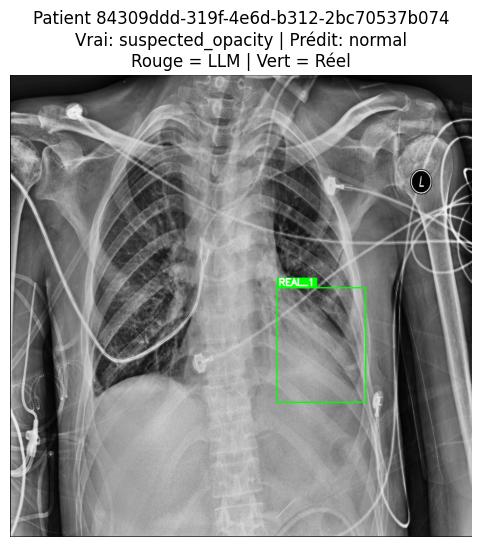

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.



--- REPONSE DU MODELE (Image 18) ---
```json
{
  "image_quality": "good",
  "predicted_class": "normal",
  "opacities": [],
  "confidence": 0.99,
  "visual_evidence": [
    "The lungs appear clear with no focal consolidation or infiltrates.",
    "The heart size and mediastinal contours are within normal limits.",
    "The ribs and clavicles are intact."
  ],
  "justification": "The chest X-ray shows clear lung fields without any signs of consolidation, infiltrates, or masses. The heart size and mediastinal structures appear normal. There are no obvious abnormalities.",
  "limitations": [
    "This is a single frontal view, which may not capture the full extent of the lungs."
  ],
  "warning": "Prototype pédagogique. Non destiné au diagnostic médical."
}
```
---------------------------------------

Image 18/20 | Vrai: normal            | Prédit: normal


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.



--- REPONSE DU MODELE (Image 19) ---
```json
{
  "image_quality": "good",
  "predicted_class": "normal",
  "opacities": [],
  "confidence": 0.99,
  "visual_evidence": [
    "The lungs appear clear with no focal consolidation or infiltrates.",
    "The heart size is within normal limits.",
    "The mediastinum is unremarkable."
  ],
  "justification": "The chest X-ray shows clear lung fields without any obvious signs of consolidation, infiltrates, or masses. The heart size appears normal, and the mediastinal structures are unremarkable. There are no features suggestive of pneumonia.",
  "limitations": [
    "This is a single frontal view, which may not capture the full extent of the lungs."
  ],
  "warning": "Prototype pédagogique. Non destiné au diagnostic médical."
}
```
---------------------------------------

Image 19/20 | Vrai: normal            | Prédit: normal

--- REPONSE DU MODELE (Image 20) ---
```json
{
  "image_quality": "good",
  "predicted_class": "suspected_opacity",
  "

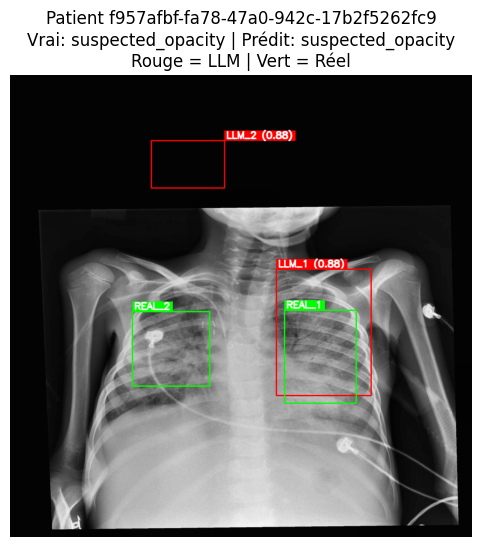

In [18]:
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import time, json
import pandas as pd

def draw_bounding_box(image_array, coordinates, label, color=(255, 0, 0)):
    """Draw a single bounding box on an RGB numpy array.
    coordinates = [y1, x1, y2, x2], normalized 0-1024.
    Fonction réservée aux prédictions du modèle.
    """
    height, width = image_array.shape[:2]
    y1, x1, y2, x2 = [int(c) / 1024 for c in coordinates]
    y1, x1, y2, x2 = round(y1 * height), round(x1 * width), round(y2 * height), round(x2 * width)

    text_size, _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
    text_w, text_h = text_size

    label_y = max(text_h + 4, y1)
    cv2.rectangle(image_array, (x1, label_y - text_h - 6), (x1 + text_w + 8, label_y), color, -1)
    cv2.putText(image_array, label, (x1 + 4, label_y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2, cv2.LINE_AA)
    cv2.rectangle(image_array, (x1, y1), (x2, y2), color, 2)
    return image_array


def draw_csv_bounding_box(image_array, x, y, box_width, box_height, label, color=(0, 255, 0), source_size=1024):
    """Draw a ground-truth bounding box from the CSV on an RGB numpy array.

    CSV format:
    x, y, width, height

    Ces coordonnées sont en pixels sur l'image d'origine 1024x1024.
    On les adapte à la taille réelle de image_array si process_dicom redimensionne l'image.
    """
    img_h, img_w = image_array.shape[:2]

    x = float(x)
    y = float(y)
    box_width = float(box_width)
    box_height = float(box_height)

    scale_x = img_w / source_size
    scale_y = img_h / source_size

    x1 = round(x * scale_x)
    y1 = round(y * scale_y)
    x2 = round((x + box_width) * scale_x)
    y2 = round((y + box_height) * scale_y)

    x1 = max(0, min(img_w - 1, x1))
    y1 = max(0, min(img_h - 1, y1))
    x2 = max(0, min(img_w - 1, x2))
    y2 = max(0, min(img_h - 1, y2))

    if x2 <= x1 or y2 <= y1:
        return image_array

    text_size, _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
    text_w, text_h = text_size

    label_y = max(text_h + 4, y1)
    cv2.rectangle(image_array, (x1, label_y - text_h - 6), (x1 + text_w + 8, label_y), color, -1)
    cv2.putText(image_array, label, (x1 + 4, label_y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2, cv2.LINE_AA)
    cv2.rectangle(image_array, (x1, y1), (x2, y2), color, 2)

    return image_array


# Chargement des vraies boîtes depuis le CSV
train_labels_df = pd.read_csv(TRAIN_LABELS_CSV)

# On garde uniquement les lignes positives avec une vraie bbox
true_boxes_df = train_labels_df[
    (train_labels_df["Target"] == 1)
    & train_labels_df[["x", "y", "width", "height"]].notna().all(axis=1)
].copy()


results = []
subset_eval = df_subset.head(20)
print("Début de l'inférence...")

for idx, row in subset_eval.iterrows():
    patient_id = row['patientId']
    img = process_dicom(patient_id)
    if img is None:
        continue

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": f"{BASELINE_PROMPT}\n\nAnalyze the following image."}
            ]
        }
    ]

    prompt_formate = processor.apply_chat_template(messages, add_generation_prompt=True, tokenize=False)
    inputs = processor(text=prompt_formate, images=img, return_tensors="pt").to(model.device)

    start_time = time.time()
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=1024,
        )
    latency = time.time() - start_time

    input_len = inputs["input_ids"].shape[1]
    generated_tokens = outputs[0][input_len:]
    response_text = processor.decode(generated_tokens, skip_special_tokens=True).strip()

    print(f"\n--- REPONSE DU MODELE (Image {idx+1}) ---")
    print(response_text)
    print("---------------------------------------\n")

    # Parsing JSON
    try:
        start_idx = response_text.find("{")
        end_idx = response_text.rfind("}") + 1
        if start_idx != -1 and end_idx != 0:
            json_str = response_text[start_idx:end_idx]
            pred_json = json.loads(json_str)
        else:
            raise ValueError("Aucun JSON détecté")
    except Exception as e:
        pred_json = {
            "predicted_class": "uncertain",
            "confidence": 0.0,
            "error": f"Erreur parsing: {str(e)}"
        }

    if pred_json.get("confidence", 0.0) < 0.6:
        pred_json["predicted_class"] = "uncertain"

    results.append({
        "patientId": patient_id,
        "true_class": row['project_class'],
        "predicted_class": pred_json.get("predicted_class", "uncertain"),
        "confidence": pred_json.get("confidence", 0.0),
        "latency": latency,
        "full_json": json.dumps(pred_json)
    })

    print(f"Image {idx+1}/{len(subset_eval)} | Vrai: {row['project_class']:<17} | Prédit: {pred_json.get('predicted_class')}")

    # --- Dessin des boîtes prédites + boîtes réelles ---
    try:
        annotated = np.array(img.convert("RGB"))
        has_box_to_display = False

        # 1) Boîtes prédites par le modèle : ROUGE
        if pred_json.get("predicted_class") == "suspected_opacity":
            opacities = pred_json.get("opacities", [])

            if opacities:
                for i, opacity in enumerate(opacities):
                    box = opacity.get("box_2d")

                    if box and isinstance(box, (list, tuple)) and len(box) == 4 and all(v is not None for v in box):
                        label = f"LLM_{i+1} ({pred_json.get('confidence', 0):.2f})"
                        annotated = draw_bounding_box(
                            annotated,
                            box,
                            label,
                            color=(255, 0, 0)
                        )
                        has_box_to_display = True
                    else:
                        print(f"[Attention] '{patient_id}' opacity #{i+1} invalide: {box}")
            else:
                print(f"[Attention] '{patient_id}' classé suspected_opacity mais opacities vide/manquant: {opacities}")

        # 2) Boîtes réelles depuis le CSV : VERT
        real_boxes_patient = true_boxes_df[true_boxes_df["patientId"] == patient_id]

        if not real_boxes_patient.empty:
            for j, gt_box in enumerate(real_boxes_patient.itertuples(index=False), start=1):
                label = f"REAL_{j}"
                annotated = draw_csv_bounding_box(
                    annotated,
                    gt_box.x,
                    gt_box.y,
                    gt_box.width,
                    gt_box.height,
                    label,
                    color=(0, 255, 0)
                )
                has_box_to_display = True

        # Affichage si au moins une boîte existe : prédite ou réelle
        if has_box_to_display:
            plt.figure(figsize=(6, 6))
            plt.imshow(annotated)
            plt.title(
                f"Patient {patient_id}\n"
                f"Vrai: {row['project_class']} | Prédit: {pred_json.get('predicted_class')}\n"
                f"Rouge = LLM | Vert = Réel"
            )
            plt.axis("off")
            plt.show()

    except Exception as e:
        print(f"[Erreur dessin bbox pour {patient_id}]: {e}")


df_results = pd.DataFrame(results)

## 7. Évaluation et Métriques
Calcul des métriques (Accuracy, Macro-F1) en tenant compte de la classe "uncertain".

In [17]:
print("\n--- RÉSULTATS GLOBAUX ---")

valid_preds = df_results[df_results['predicted_class'].isin(['normal', 'suspected_opacity'])]
uncertain_rate = (len(df_results) - len(valid_preds)) / len(df_results)

print(f"Taux d'incertitude (rejets) : {uncertain_rate:.1%}")

if len(valid_preds) > 0:
    acc = accuracy_score(valid_preds['true_class'], valid_preds['predicted_class'])
    f1 = f1_score(valid_preds['true_class'], valid_preds['predicted_class'], average='macro')
    print(f"Accuracy (sur prédictions fermes) : {acc:.3f}")
    print(f"Macro F1 (sur prédictions fermes) : {f1:.3f}")
else:
    print("Toutes les prédictions ont été classées comme incertaines.")

print("\nMatrice de confusion complète :")
labels = ['normal', 'suspected_opacity', 'uncertain']
cm = confusion_matrix(df_results['true_class'], df_results['predicted_class'], labels=labels)
cm_df = pd.DataFrame(cm, index=[f"True_{l}" for l in labels], columns=[f"Pred_{l}" for l in labels])
display(cm_df)

# Sauvegarde pour analyse d'erreurs ultérieure
df_results.to_csv("baseline_results.csv", index=False)
print("\nRésultats sauvegardés dans baseline_results.csv")


--- RÉSULTATS GLOBAUX ---
Taux d'incertitude (rejets) : 0.0%
Accuracy (sur prédictions fermes) : 0.850
Macro F1 (sur prédictions fermes) : 0.840

Matrice de confusion complète :


,Pred_normal,Pred_suspected_opacity,Pred_uncertain
True_normal,11,1,0
True_suspected_opacity,2,6,0
True_uncertain,0,0,0



Résultats sauvegardés dans baseline_results.csv
